# Neuromorphic Event-Driven SSP-SLAM Demo
This end-to-end demo showcases the integration of multiple subsystems:
1. **Environment:** Gymnasium Miniworld (providing continuous RGB and Depth).
2. **Neuromorphic Simulator:** Converts RGB streams into asynchronous event pulses, bypassing normal frame persistence.
3. **Perception:** The `EventVisionAdapter` with `backend='gpert'` tracking ego-motion purely from events and extracting metric layout from the simulated GPERT Depth maps.
4. **Cognitive Mapping:** Nengo Spiking Neural Networks plotting out a spatial mapping array.


In [1]:
import numpy as np
import nengo
import sys, os, time
import matplotlib.pyplot as plt
import gymnasium as gym

sys.path.insert(1, os.path.dirname(os.getcwd()) if 'experiments' in os.getcwd() else os.getcwd())
import sspslam
import miniworld
from sspslam.networks import SLAMNetwork, get_slam_input_functions_from_features
from sspslam.perception import ImageFeatureEncoder
from sspslam.perception.event_simulator import ContrastThresholdEventSimulator
from sspslam.perception.event_vision_adapter import EventVisionAdapter

def stretch_array(arr, orig_dt, new_dt):
    n_steps = arr.shape[0]
    total_time = n_steps * orig_dt
    n_timesteps = int(total_time / new_dt)
    orig_t = np.linspace(0, total_time, n_steps)
    new_t = np.linspace(0, total_time, n_timesteps)
    if arr.ndim == 2:
        return np.stack([np.interp(new_t, orig_t, arr[:, i]) for i in range(arr.shape[1])], axis=1)
    elif arr.ndim == 3:
        out = np.zeros((n_timesteps, arr.shape[1], arr.shape[2]))
        for n in range(arr.shape[1]):
            for d in range(arr.shape[2]):
                out[:, n, d] = np.interp(new_t, orig_t, arr[:, n, d])
        return out
    return arr


## 1. Collect Normal Camera Context and Depths
We step an agent through Miniworld, recording its Ground Truth path for validation, retrieving RGB frames, and rendering exact metrics to serve as our Simulated GPERT Depth.


In [2]:
print("Generating Data from MiniWorld...")
env = gym.make("MiniWorld-ThreeRooms-v0", render_mode="rgb_array")
env.reset()

max_steps = 100
dt_env = 0.05
rgb_frames = []
depth_maps = []
path = []

last_pos = np.array([env.unwrapped.agent.pos[0], env.unwrapped.agent.pos[2]])
path.append(last_pos)

for t in range(max_steps):
    action = 2 if t % 10 != 0 else 0
    obs, _, term, trunc, _ = env.step(action)
    
    rgb_frames.append(obs)
    depth_maps.append(env.unwrapped.render_depth())
    
    current_pos = np.array([env.unwrapped.agent.pos[0], env.unwrapped.agent.pos[2]])
    path.append(current_pos)
    
    if term or trunc:
        break

rgb_frames = np.array(rgb_frames)
path = np.array(path)
print(f"Collected {len(rgb_frames)} RGB frames. Path length: {len(path)}.")


Generating Data from MiniWorld...
Collected 100 RGB frames. Path length: 101.


Collected 100 RGB frames. Path length: 101.


## 2. Neuromorphic Event Stimulation
We pass the sequences of dense RGB data into `ContrastThresholdEventSimulator` to spawn dynamic, temporal event point-clouds over contrast edges.


Simulating Event Fields...
Generated 25681 events across 98 time bins.


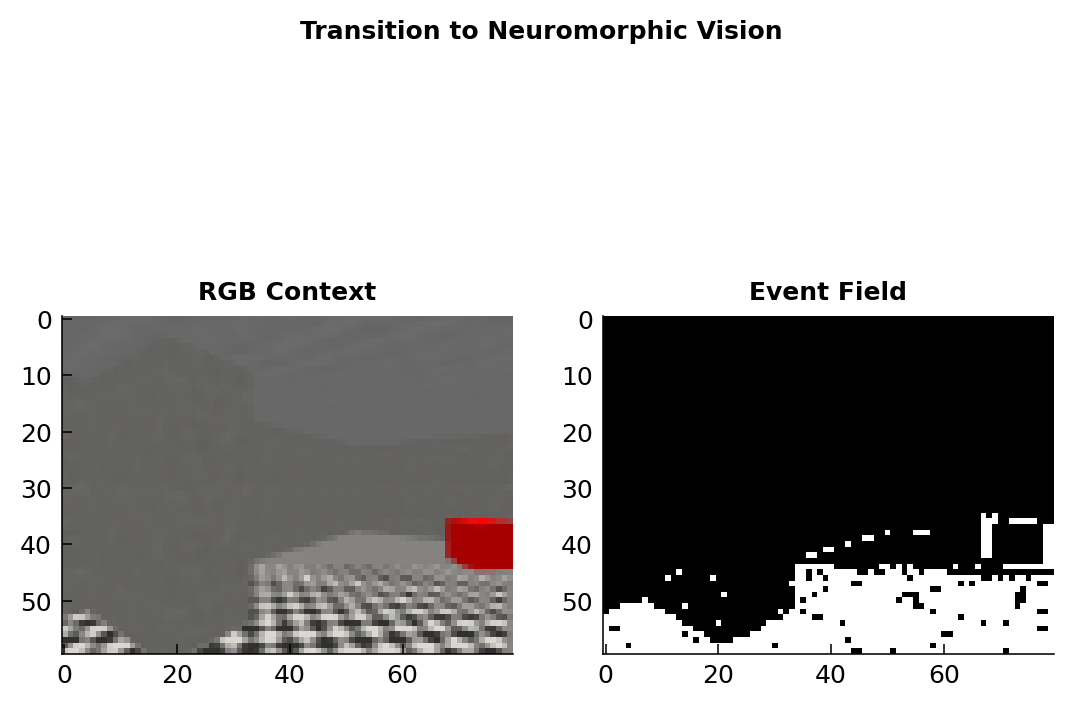

In [3]:
print("Simulating Event Fields...")
event_sim = ContrastThresholdEventSimulator(C_pos=0.15, C_neg=0.15, dt=dt_env)
event_frames, times, raw_events = event_sim.simulate(rgb_frames, dt_window=dt_env)
print(f"Generated {len(raw_events)} events across {len(event_frames)} time bins.")

# Plot to verify
plt.figure()
plt.suptitle("Transition to Neuromorphic Vision")
plt.subplot(1, 2, 1)
plt.title("RGB Context")
plt.imshow(rgb_frames[-1])
plt.subplot(1, 2, 2)
plt.title("Event Field")
plt.imshow(event_frames[-1], cmap='gray')
def save_or_show():
    # Helper to accommodate headless CI / CLI running
    try:
        import IPython
        if IPython.get_ipython() is not None:
            plt.show()
            return
    except ImportError:
        pass
    plt.savefig("experiments/demo_transition.png")
save_or_show()


## 3. Feature Mapping with the GPERT Backend
We instantiate `EventVisionAdapter(backend='gpert')`. This passes tracking points over to the `EventOdometry` (EVO) block to generate agent-agnostic continuous ego-motion vectors, whilst using the `SimulatedGPERTAdapter` proxy depths to map metric visual arrays.


In [4]:
print("Executing Feature Adapter (EVO + Simulated 3D Depth) via GPERT Backend...")
# Max persistent targets
max_landmarks = 20
view_rad = 4.0

adapter = EventVisionAdapter(max_landmarks=max_landmarks, view_radius=view_rad, backend='gpert')
vel_data, vec_to_landmarks_data, feat_data = adapter.process_dataset(
    event_frames, 
    landmark_depths=depth_maps[:len(event_frames)]
)

print(f"EVO computed velocities shape: {vel_data.shape}")
print(f"Metric vectors shape: {vec_to_landmarks_data.shape}")


Executing Feature Adapter (EVO + Simulated 3D Depth) via GPERT Backend...
EVO computed velocities shape: (98, 2)
Metric vectors shape: (98, 20, 2)


## 4. Cognitive Map Construction via SSP-SLAM Spiking Network
The metric features and tracked velocities are stretched to accommodate the 1ms continuous differential equations resolved inside Nengo networks.


Interpolating constraints for Spiking Integration...
Building Network Topology...
Initiating Neuromorphic Simulation...


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

Decoding Neural Activity Array into Path Vectors...
Mean spatial error against ground truth: 8.7938 units


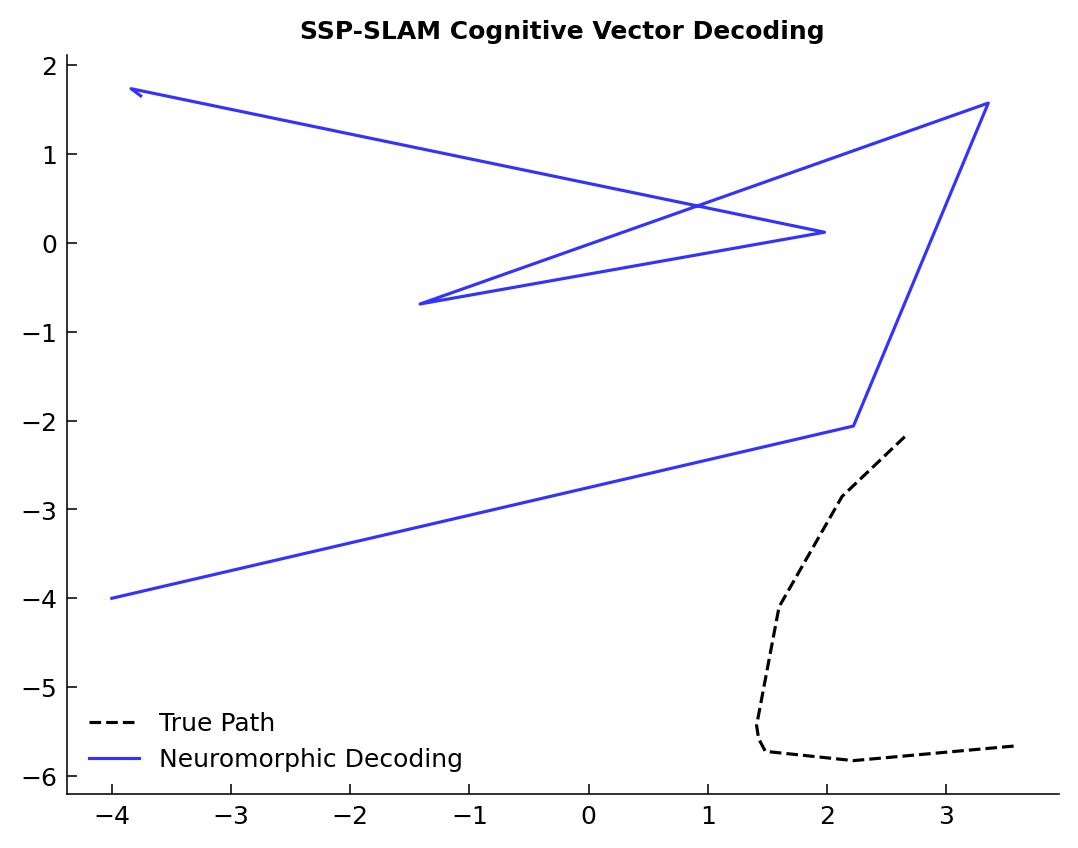

Demo Completed.


In [5]:
sim_dt = 0.001
print("Interpolating constraints for Spiking Integration...")
vel_data_sim = stretch_array(vel_data, dt_env, sim_dt)
vec_data_sim = stretch_array(vec_to_landmarks_data, dt_env, sim_dt)
feat_data_sim = stretch_array(feat_data, dt_env, sim_dt)
path_sim = stretch_array(path[:len(event_frames)], dt_env, sim_dt)
T_sim = len(event_frames) * dt_env

ssp_dim = 97
domain_dim = 2
radius = 4.0

bounds = radius * np.tile([-1, 1], (domain_dim, 1))
ssp_space = sspslam.HexagonalSSPSpace(domain_dim, ssp_dim=ssp_dim, domain_bounds=bounds, length_scale=0.5, seed=0)
d = ssp_space.ssp_dim
real_ssp = ssp_space.encode(path_sim)

feature_encoder = ImageFeatureEncoder(feat_dim=32, ssp_dim=d, seed=0)

fns = get_slam_input_functions_from_features(
    ssp_space, feature_encoder, vel_data_sim, vec_data_sim, feat_data_sim, view_rad, dt=sim_dt
)
(velocity_func, vel_scaling_factor, is_landmark_in_view, 
 landmark_id_func, landmark_sp_func, landmark_vec_func, landmark_vecssp_func) = fns

landmark_sps_precomputed = feature_encoder.encode(feat_data_sim.mean(axis=0))
lm_space = sspslam.SPSpace(max_landmarks, d, seed=0, vectors=landmark_sps_precomputed)

print("Building Network Topology...")
model = nengo.Network(seed=0)
with model:
    vel_input = nengo.Node(velocity_func)
    init_state = nengo.Node(lambda t: real_ssp[int((t - sim_dt) / sim_dt)] if t < 0.05 else np.zeros(d))
    landmark_vec_node = nengo.Node(landmark_vecssp_func)
    landmark_id_node = nengo.Node(landmark_sp_func)
    is_landmark_node = nengo.Node(is_landmark_in_view)

    slam = SLAMNetwork(
        ssp_space, lm_space, view_rad, max_landmarks,
        150, 200, 50, # Sub-sampled for demo speed
        tau_pi=0.05, update_thres=0.5, vel_scaling_factor=vel_scaling_factor,
        shift_rate=0.1, clean_up_method="grid", voja=True, seed=0,
    )

    nengo.Connection(vel_input, slam.velocity_input, synapse=None)
    nengo.Connection(init_state, slam.pathintegrator.input, synapse=None)
    nengo.Connection(landmark_vec_node, slam.landmark_vec_ssp, synapse=None)
    nengo.Connection(landmark_id_node, slam.landmark_id_input, synapse=None)
    nengo.Connection(is_landmark_node, slam.no_landmark_in_view, synapse=None)

    slam_output_p = nengo.Probe(slam.pathintegrator.output, synapse=0.05)

print("Initiating Neuromorphic Simulation...")
try:
    with nengo.Simulator(model) as sim:
        sim.run(T_sim)
    
    print("Decoding Neural Activity Array into Path Vectors...")
    slam_out = sim.data[slam_output_p]
    sim_path_est = ssp_space.decode(slam_out, "from-set", "grid", 100)
    
    trim_len = min(path_sim.shape[0], sim_path_est.shape[0])
    p_sim = path_sim[:trim_len]
    p_est = sim_path_est[:trim_len]
    
    slam_error = np.sqrt(np.sum((p_sim - p_est) ** 2, axis=1))
    print(f"Mean spatial error against ground truth: {slam_error.mean():.4f} units")
    
    plt.figure()
    plt.title("SSP-SLAM Cognitive Vector Decoding")
    plt.plot(p_sim[:,0], p_sim[:,1], 'k--', label="True Path")
    plt.plot(p_est[:,0], p_est[:,1], 'b-', alpha=0.8, label="Neuromorphic Decoding")
    plt.legend()
    save_or_show()

except nengo.exceptions.BuildError as e:
    print(f"Failed to build Nengo arrays due to sparsity constraints: {e}")
except Exception as e:
    print(f"Error executing graph: {e}")

print("Demo Completed.")
